# Independent Validation of the Weekly Cryptocurrency Momentum Model

The model was developed using data from 2023–2024 and is validated using the untouched 2025 period.

The strategy uses a seven-day momentum signal, selects the top three cryptocurrencies, applies equal weights and rebalances weekly.

All model rules were fixed before the 2025 out-of-sample validation.

In [17]:
# frozen parameters

SIGNAL_HORIZON_HOURS = 168
NUMBER_OF_ASSETS = 3
REBALANCE_DAY = 0          # Monday
REBALANCE_HOUR = 0         # 00:00 UTC
TRANSACTION_COST_RATE = 0.002

## Frozen Model Specification

The following model parameters were selected during the 2023–2024 development period and are not modified during validation:

- Signal horizon: 168 hours
- Portfolio: top three momentum assets
- Portfolio type: long-only
- Weighting: equal weighted
- Rebalancing frequency: weekly
- Rebalancing time: Monday at 00:00 UTC
- Execution cost: 20 basis points per unit of turnover

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [19]:
# step 1: Load the cleaned hourly cryptocurrency panel

project_root = Path("/Users/nimo/crypto-statistical-arbitrage")

data_path = (
    project_root
    / "data"
    / "processed"
    / "crypto_10_assets_1h_clean.parquet"
)

df = pd.read_parquet(data_path)

df = (
    df
    .sort_values(["symbol", "open_time"])
    .reset_index(drop=True)
)

print(df.shape)
print(df["open_time"].min())
print(df["open_time"].max())

df.head()

(263030, 11)
2023-01-01 00:00:00+00:00
2025-12-31 23:00:00+00:00


,open_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,symbol
0,2023-01-01 00:00:00+00:00,0.2458,0.2459,0.2441,0.2445,4476440.1,1.096436e+06,1979,2325058.2,569457.21279,ADAUSDT
1,2023-01-01 01:00:00+00:00,0.2446,0.2455,0.2443,0.2452,2247531.8,5.498366e+05,1110,1176230.7,287778.97095,ADAUSDT
2,2023-01-01 02:00:00+00:00,0.2452,0.2462,0.2449,0.2456,1878723.3,4.616204e+05,923,993206.7,243976.96105,ADAUSDT
3,2023-01-01 03:00:00+00:00,0.2456,0.2458,0.2452,0.2454,2778149.2,6.818411e+05,1139,1332950.4,327156.00797,ADAUSDT
4,2023-01-01 04:00:00+00:00,0.2454,0.2455,0.2444,0.2446,1326482.4,3.247254e+05,807,574781.7,140711.28901,ADAUSDT


In [21]:
# step 2: Calculate hourly returns and next-hour returns

df["return_1h"] = (
    df.groupby("symbol")["close"]
    .pct_change()
)

df["future_return_1h"] = (
    df.groupby("symbol")["return_1h"]
    .shift(-1)
)

In [23]:
# step 3: Calculate validation signals
validation_source_df = (
    df
    .sort_values(["symbol", "open_time"])
    .copy()
)

validation_source_df["signal_168h"] = (
    validation_source_df
    .groupby("symbol")["close"]
    .pct_change(periods=168)
)

validation_source_df["rank_168h"] = (
    validation_source_df
    .groupby("open_time")["signal_168h"]
    .rank(
        method="first",
        ascending=True,
    )
)

In [25]:
# step 4: seperate data in 2025
validation_df = (
    validation_source_df[
        validation_source_df["open_time"]
        >= "2025-01-01"
    ]
    .copy()
)

print(validation_df["open_time"].min())
print(validation_df["open_time"].max())
print(validation_df.shape)

2025-01-01 00:00:00+00:00
2025-12-31 23:00:00+00:00
(87600, 15)


## Validation Portfolio Construction

The frozen weekly momentum strategy is now reconstructed independently using the 2025 out-of-sample data.

The strategy ranks cryptocurrencies using their previous 168-hour returns, selects the top three assets every Monday at 00:00 UTC and holds them with equal weights until the next weekly rebalancing date.

In [28]:
# Step 5: create validation rank and return matrices

validation_rank_wide = (
    validation_df
    .pivot(
        index="open_time",
        columns="symbol",
        values="rank_168h",
    )
    .sort_index()
)

validation_future_return_wide = (
    validation_df
    .pivot(
        index="open_time",
        columns="symbol",
        values="future_return_1h",
    )
    .sort_index()
)

print(validation_rank_wide.shape)
print(validation_future_return_wide.shape)

(8760, 10)
(8760, 10)


In [30]:
# Step 6: identify weekly rebalance times

validation_rebalance_times = (
    validation_rank_wide.index[
        (validation_rank_wide.index.dayofweek == REBALANCE_DAY)
        & (validation_rank_wide.index.hour == REBALANCE_HOUR)
    ]
)

print("Number of scheduled rebalance dates:")
print(len(validation_rebalance_times))

validation_rebalance_times[:5]

Number of scheduled rebalance dates:
52


DatetimeIndex(['2025-01-06 00:00:00+00:00', '2025-01-13 00:00:00+00:00',
               '2025-01-20 00:00:00+00:00', '2025-01-27 00:00:00+00:00',
               '2025-02-03 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='open_time', freq=None)

In [32]:
# Step 7: construct validation portfolio weights

validation_weights = pd.DataFrame(
    np.nan,
    index=validation_rank_wide.index,
    columns=validation_rank_wide.columns,
)

for current_time in validation_rebalance_times:

    current_ranks = (
        validation_rank_wide
        .loc[current_time]
        .dropna()
    )

    # Require all ten cryptocurrencies
    if len(current_ranks) < 10:
        continue

    selected_assets = (
        current_ranks
        .nlargest(NUMBER_OF_ASSETS)
        .index
    )

    validation_weights.loc[
        current_time,
        :
    ] = 0.0

    validation_weights.loc[
        current_time,
        selected_assets,
    ] = 1 / NUMBER_OF_ASSETS

In [34]:
# Step 8: hold portfolio weights until the next rebalance

validation_weights = (
    validation_weights
    .ffill()
    .fillna(0.0)
)

In [36]:
# step 9: implementation checks
validation_position_count = (
    validation_weights > 0
).sum(axis=1)

validation_position_count.describe()

count    8760.000000
mean        2.958904
std         0.348730
min         0.000000
25%         3.000000
50%         3.000000
75%         3.000000
max         3.000000
dtype: float64

In [40]:
# step 9.2: weight check
np.sort(
    validation_weights
    .stack()
    .unique()
)

array([0.        , 0.33333333])

In [42]:
# step 9.3: exposure
validation_exposure = pd.DataFrame(
    {
        "net_exposure": validation_weights.sum(axis=1),
        "gross_exposure": (
            validation_weights.abs().sum(axis=1)
        ),
    }
)

validation_exposure.describe()

,net_exposure,gross_exposure
count,8760.000000,8760.000000
mean,0.986301,0.986301
std,0.116243,0.116243
min,0.000000,0.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,1.000000,1.000000


## Out-of-Sample Performance Evaluation

The validated portfolio implementation is now evaluated using the 2025 out-of-sample period.

Performance is assessed using gross returns, turnover, transaction costs, net returns, Sharpe Ratio, Maximum Drawdown and cumulative portfolio value.

In [45]:
# Step 10: calculate validation gross returns

validation_contributions = (
    validation_weights
    * validation_future_return_wide
)

validation_strategy = (
    validation_contributions
    .sum(axis=1, min_count=1)
    .rename("gross_return")
    .to_frame()
)

validation_strategy["gross_return"] = (
    validation_strategy["gross_return"]
    .fillna(0)
)

In [47]:
# Step 11: calculate turnover and transaction costs

validation_strategy["turnover"] = (
    validation_weights
    .diff()
    .fillna(0)
    .abs()
    .sum(axis=1)
)

validation_strategy["transaction_cost"] = (
    validation_strategy["turnover"]
    * TRANSACTION_COST_RATE
)

validation_strategy["net_return"] = (
    validation_strategy["gross_return"]
    - validation_strategy["transaction_cost"]
)

In [49]:
# step 12: result:
validation_summary = pd.Series(
    {
        "number_of_rebalances": (
            validation_strategy["turnover"]
            .gt(0)
            .sum()
        ),
        "average_gross_return": (
            validation_strategy["gross_return"]
            .mean()
        ),
        "average_turnover": (
            validation_strategy["turnover"]
            .mean()
        ),
        "average_transaction_cost": (
            validation_strategy[
                "transaction_cost"
            ]
            .mean()
        ),
        "average_net_return": (
            validation_strategy["net_return"]
            .mean()
        ),
    }
)

validation_summary

number_of_rebalances        52.000000
average_gross_return        -0.000019
average_turnover             0.008409
average_transaction_cost     0.000017
average_net_return          -0.000036
dtype: float64

In [ ]:
# the model doesn't work in year 2025

In [51]:
# step 13: sharpes and mdd
HOURS_PER_YEAR = 24 * 365
def calculate_maximum_drawdown(
    returns: pd.Series,
) -> float:
    cumulative_value = (
        1 + returns.fillna(0)
    ).cumprod()

    running_maximum = (
        cumulative_value.cummax()
    )

    drawdown = (
        cumulative_value
        / running_maximum
        - 1
    )

    return drawdown.min()
    

In [53]:


validation_gross_mean = (
    validation_strategy["gross_return"]
    .mean()
)

validation_net_mean = (
    validation_strategy["net_return"]
    .mean()
)

validation_gross_vol = (
    validation_strategy["gross_return"]
    .std()
)

validation_net_vol = (
    validation_strategy["net_return"]
    .std()
)

validation_gross_sharpe = (
    validation_gross_mean
    / validation_gross_vol
    * np.sqrt(HOURS_PER_YEAR)
)

validation_net_sharpe = (
    validation_net_mean
    / validation_net_vol
    * np.sqrt(HOURS_PER_YEAR)
)

validation_gross_mdd = (
    calculate_maximum_drawdown(
        validation_strategy[
            "gross_return"
        ]
    )
)

validation_net_mdd = (
    calculate_maximum_drawdown(
        validation_strategy[
            "net_return"
        ]
    )
)

print(
    "Validation Gross Sharpe:",
    validation_gross_sharpe,
)

print(
    "Validation Net Sharpe:",
    validation_net_sharpe,
)

print(
    "Validation Gross Maximum Drawdown:",
    validation_gross_mdd,
)

print(
    "Validation Net Maximum Drawdown:",
    validation_net_mdd,
)

Validation Gross Sharpe: -0.23842933940791552
Validation Net Sharpe: -0.4438914154251479
Validation Gross Maximum Drawdown: -0.5441896154656137
Validation Net Maximum Drawdown: -0.5581064364922853


In [ ]:
# last two years, sharp positive, but this year negative, strategy not stable
# the strategy may depends on market
# mdd: 56% very high

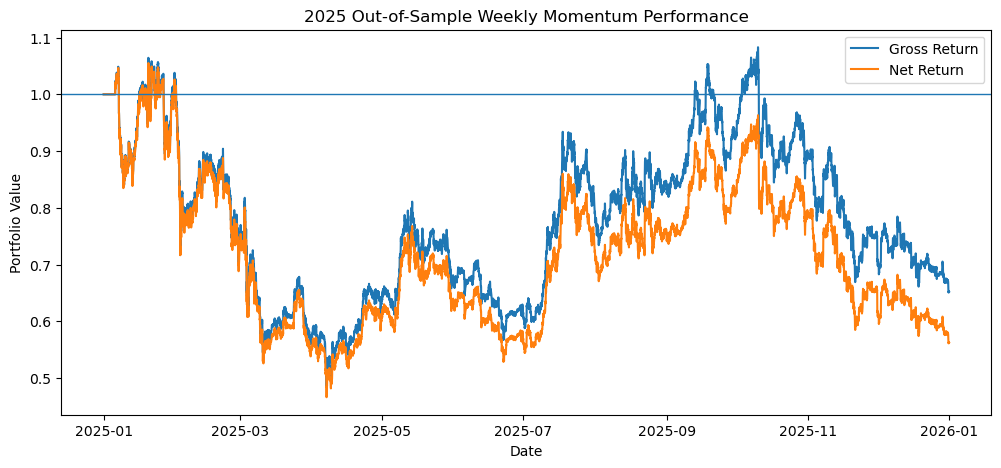

In [55]:
# Step 14: calculate cumulative validation performance

validation_strategy[
    "cumulative_gross_return"
] = (
    1
    + validation_strategy[
        "gross_return"
    ]
).cumprod()

validation_strategy[
    "cumulative_net_return"
] = (
    1
    + validation_strategy[
        "net_return"
    ]
).cumprod()

plt.figure(figsize=(12, 5))

plt.plot(
    validation_strategy.index,
    validation_strategy[
        "cumulative_gross_return"
    ],
    label="Gross Return",
)

plt.plot(
    validation_strategy.index,
    validation_strategy[
        "cumulative_net_return"
    ],
    label="Net Return",
)

plt.axhline(1, linewidth=1)

plt.title(
    "2025 Out-of-Sample Weekly Momentum Performance"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()

plt.show()

In [57]:
# at begining, increase to 1.05, then decrease
# yearly decrease 44%

In [59]:
validation_strategy[
    "cumulative_net_return"
].iloc[-1]

0.562608434384205

### Out-of-Sample Performance Finding

The weekly long-only momentum strategy did not maintain its development-sample performance during the 2025 out-of-sample validation period.

Average gross and net returns were both negative. The gross Sharpe Ratio declined from a positive development-sample value to approximately -0.24, while the net Sharpe Ratio declined to approximately -0.44.

The strategy also experienced a net Maximum Drawdown of approximately 56%, indicating substantial downside risk without corresponding positive returns.

Because gross returns were negative before execution costs, the 2025 underperformance cannot be attributed solely to transaction costs. The underlying seven-day momentum signal itself was not stable across the validation period.

This represents a material performance-stability limitation and suggests that the strategy is sensitive to changing cryptocurrency market regimes.

## Equal-Weight Benchmark Comparison

The validated weekly momentum strategy is compared with a simple equal-weight cryptocurrency benchmark.

The benchmark holds all ten cryptocurrencies with equal weights and follows the same weekly rebalancing schedule and 20-basis-point transaction-cost assumption as the momentum strategy.

This comparison assesses whether momentum-based asset selection adds value beyond broad cryptocurrency market exposure.

In [64]:
# Step 14.1: construct weekly equal-weight benchmark weights

benchmark_weights = pd.DataFrame(
    np.nan,
    index=validation_future_return_wide.index,
    columns=validation_future_return_wide.columns,
)

for current_time in validation_rebalance_times:

    available_assets = (
        validation_future_return_wide
        .loc[current_time]
        .dropna()
        .index
    )

    # Require all ten cryptocurrencies
    if len(available_assets) < 10:
        continue

    benchmark_weights.loc[
        current_time,
        :
    ] = 1 / len(available_assets)

In [66]:
# Step 14.2: hold benchmark weights until the next rebalance

benchmark_weights = (
    benchmark_weights
    .ffill()
    .fillna(0.0)
)

In [68]:
# step 14.3: check position count
benchmark_position_count = (
    benchmark_weights > 0
).sum(axis=1)

benchmark_position_count.describe()

count    8760.000000
mean        9.863014
std         1.162434
min         0.000000
25%        10.000000
50%        10.000000
75%        10.000000
max        10.000000
dtype: float64

In [70]:
# step 14.4: check weight
np.sort(
    benchmark_weights
    .stack()
    .unique()
)

array([0. , 0.1])

In [72]:
# step 14.5 check exposure
benchmark_exposure = pd.DataFrame(
    {
        "net_exposure": benchmark_weights.sum(axis=1),
        "gross_exposure": benchmark_weights.abs().sum(axis=1),
    }
)

benchmark_exposure.describe()

,net_exposure,gross_exposure
count,8760.000000,8760.000000
mean,0.986301,0.986301
std,0.116243,0.116243
min,0.000000,0.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,1.000000,1.000000


In [74]:
# Step 14.6: calculate benchmark gross returns

benchmark_contributions = (
    benchmark_weights
    * validation_future_return_wide
)

validation_benchmark = (
    benchmark_contributions
    .sum(axis=1, min_count=1)
    .rename("gross_return")
    .to_frame()
)

validation_benchmark["gross_return"] = (
    validation_benchmark["gross_return"]
    .fillna(0)
)

In [76]:
# Step 14.7: calculate benchmark turnover and transaction costs

validation_benchmark["turnover"] = (
    benchmark_weights
    .diff()
    .fillna(0)
    .abs()
    .sum(axis=1)
)

validation_benchmark["transaction_cost"] = (
    validation_benchmark["turnover"]
    * TRANSACTION_COST_RATE
)

validation_benchmark["net_return"] = (
    validation_benchmark["gross_return"]
    - validation_benchmark["transaction_cost"]
)

In [78]:
# Step 14.8: calculate benchmark performance metrics

benchmark_gross_mean = (
    validation_benchmark["gross_return"].mean()
)

benchmark_net_mean = (
    validation_benchmark["net_return"].mean()
)

benchmark_gross_vol = (
    validation_benchmark["gross_return"].std()
)

benchmark_net_vol = (
    validation_benchmark["net_return"].std()
)

benchmark_gross_sharpe = (
    benchmark_gross_mean
    / benchmark_gross_vol
    * np.sqrt(HOURS_PER_YEAR)
)

benchmark_net_sharpe = (
    benchmark_net_mean
    / benchmark_net_vol
    * np.sqrt(HOURS_PER_YEAR)
)

benchmark_gross_mdd = calculate_maximum_drawdown(
    validation_benchmark["gross_return"]
)

benchmark_net_mdd = calculate_maximum_drawdown(
    validation_benchmark["net_return"]
)

In [80]:
# step 14.9: calculate cumulate value
validation_benchmark[
    "cumulative_gross_return"
] = (
    1 + validation_benchmark["gross_return"]
).cumprod()

validation_benchmark[
    "cumulative_net_return"
] = (
    1 + validation_benchmark["net_return"]
).cumprod()

In [82]:
validation_momentum_final_value = (
    validation_strategy[
        "cumulative_net_return"
    ].iloc[-1]
)

validation_benchmark_final_value = (
    validation_benchmark[
        "cumulative_net_return"
    ].iloc[-1]
)

In [84]:
# step 14.10 : compare
validation_comparison = pd.DataFrame(
    {
        "Weekly Momentum": [
            validation_net_mean,
            validation_net_vol,
            validation_net_sharpe,
            validation_net_mdd,
            validation_momentum_final_value,
            validation_strategy["turnover"].mean(),
        ],

        "Equal-Weight Benchmark": [
            benchmark_net_mean,
            benchmark_net_vol,
            benchmark_net_sharpe,
            benchmark_net_mdd,
            validation_benchmark_final_value,
            validation_benchmark["turnover"].mean(),
        ],
    },
    index=[
        "Average Hourly Net Return",
        "Hourly Net Volatility",
        "Annualized Net Sharpe Ratio",
        "Net Maximum Drawdown",
        "Final Portfolio Value",
        "Average Turnover",
    ],
)

validation_comparison

,Weekly Momentum,Equal-Weight Benchmark
Average Hourly Net Return,-0.000036,-0.000024
Hourly Net Volatility,0.007652,0.007629
Annualized Net Sharpe Ratio,-0.443891,-0.299052
Net Maximum Drawdown,-0.558106,-0.523078
Final Portfolio Value,0.562608,0.625591
Average Turnover,0.008409,0.000114


In [ ]:
# 1: 2025 benchmark decrease to 0.6256, loose 37.44%, market bad
# The strategy's losses are not entirely due to model selection errors; but also market

# 2: momentum (0.5626) is worse than benchmark (0.6256), 
#The problem in 2025 was not just the market decline, but model not stable

# very big turnover

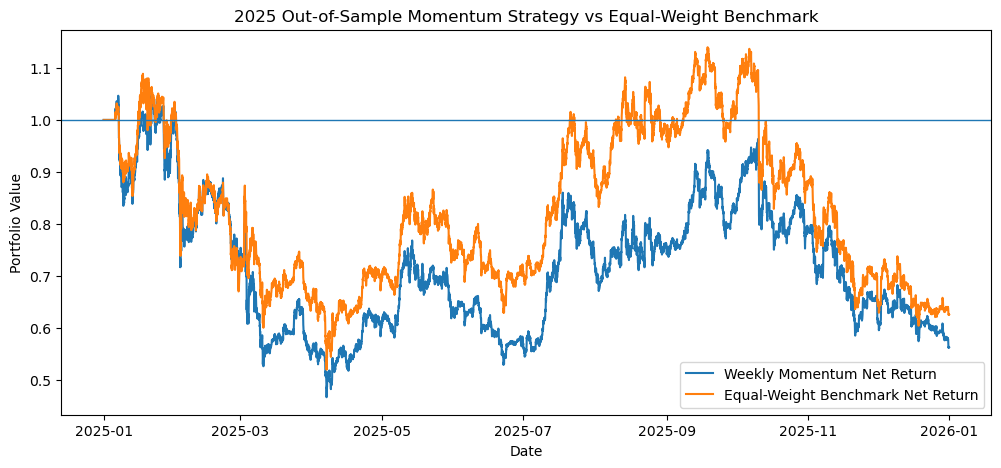

In [86]:
# step 14.11: plot
plt.figure(figsize=(12, 5))

plt.plot(
    validation_strategy.index,
    validation_strategy[
        "cumulative_net_return"
    ],
    label="Weekly Momentum Net Return",
)

plt.plot(
    validation_benchmark.index,
    validation_benchmark[
        "cumulative_net_return"
    ],
    label="Equal-Weight Benchmark Net Return",
)

plt.axhline(
    1,
    linewidth=1,
)

plt.title(
    "2025 Out-of-Sample Momentum Strategy vs Equal-Weight Benchmark"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()

plt.show()

### 2025 Benchmark Comparison Finding

- Both the weekly momentum strategy and the equal-weight cryptocurrency benchmark produced negative returns during the 2025 out-of-sample period.
- This suggests that the overall cryptocurrency market environment was unfavourable during 2025.
- The weekly momentum strategy underperformed the benchmark across all major performance metrics.
- It produced a lower final portfolio value.
- It had a more negative Sharpe Ratio.
- It experienced a larger Maximum Drawdown.
- It generated substantially higher turnover.
- The top-three momentum selection rule therefore did not add value relative to a simple diversified cryptocurrency portfolio.
- The strategy's underperformance cannot be explained solely by weak market conditions or transaction costs, because the benchmark performed better under the same market environment.

## Step 15: Alpha and Beta Analysis

An alpha-beta regression is used to assess whether the weekly momentum strategy generated returns beyond broad cryptocurrency market exposure.

The strategy's hourly net returns are regressed on the equal-weight benchmark's hourly net returns.

The analysis evaluates:

- Alpha: return not explained by benchmark exposure
- Beta: sensitivity to broad cryptocurrency market movements
- R-squared: proportion of strategy-return variation explained by the benchmark
- Statistical significance of the estimated coefficients

In [90]:
# Step 15.1: prepare alpha-beta regression data

regression_data = pd.DataFrame(
    {
        "momentum_net_return": (
            validation_strategy["net_return"]
        ),
        "benchmark_net_return": (
            validation_benchmark["net_return"]
        ),
    }
).dropna()

print(regression_data.shape)
regression_data.head()

(8760, 2)


,momentum_net_return,benchmark_net_return
open_time,,
2025-01-01 00:00:00+00:00,0.0,0.0
2025-01-01 01:00:00+00:00,0.0,0.0
2025-01-01 02:00:00+00:00,0.0,0.0
2025-01-01 03:00:00+00:00,0.0,0.0
2025-01-01 04:00:00+00:00,0.0,0.0


In [92]:
import statsmodels.api as sm
# Step 15.2: estimate alpha and beta

X = sm.add_constant(
    regression_data["benchmark_net_return"]
)

y = regression_data["momentum_net_return"]

alpha_beta_model = sm.OLS(
    y,
    X,
).fit()

print(alpha_beta_model.summary())

                             OLS Regression Results                            
Dep. Variable:     momentum_net_return   R-squared:                       0.875
Model:                             OLS   Adj. R-squared:                  0.875
Method:                  Least Squares   F-statistic:                 6.150e+04
Date:                 Wed, 29 Jul 2026   Prob (F-statistic):               0.00
Time:                         16:53:42   Log-Likelihood:                 39376.
No. Observations:                 8760   AIC:                        -7.875e+04
Df Residuals:                     8758   BIC:                        -7.873e+04
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -

In [94]:
# Step 15.3: calculate HAC-robust standard errors

alpha_beta_model_hac = (
    alpha_beta_model.get_robustcov_results(
        cov_type="HAC",
        maxlags=24,
    )
)

print(alpha_beta_model_hac.summary())

                             OLS Regression Results                            
Dep. Variable:     momentum_net_return   R-squared:                       0.875
Model:                             OLS   Adj. R-squared:                  0.875
Method:                  Least Squares   F-statistic:                     2063.
Date:                 Wed, 29 Jul 2026   Prob (F-statistic):               0.00
Time:                         16:54:39   Log-Likelihood:                 39376.
No. Observations:                 8760   AIC:                        -7.875e+04
Df Residuals:                     8758   BIC:                        -7.873e+04
Df Model:                            1                                         
Covariance Type:                   HAC                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -

In [96]:
# Step 15.4: extract key regression results

hourly_alpha = (
    alpha_beta_model_hac.params[0]
)

beta = (
    alpha_beta_model_hac.params[1]
)

alpha_p_value = (
    alpha_beta_model_hac.pvalues[0]
)

beta_p_value = (
    alpha_beta_model_hac.pvalues[1]
)

r_squared = (
    alpha_beta_model.rsquared
)

annualized_alpha_arithmetic = (
    hourly_alpha * HOURS_PER_YEAR
)

alpha_beta_summary = pd.Series(
    {
        "Hourly Alpha": hourly_alpha,
        "Annualized Alpha - Arithmetic": (
            annualized_alpha_arithmetic
        ),
        "Beta": beta,
        "Alpha P-Value": alpha_p_value,
        "Beta P-Value": beta_p_value,
        "R-Squared": r_squared,
    }
)

alpha_beta_summary

Hourly Alpha                    -0.000013
Annualized Alpha - Arithmetic   -0.117523
Beta                             0.938437
Alpha P-Value                    0.647257
Beta P-Value                     0.000000
R-Squared                        0.875338
dtype: float64

In [98]:
# Alpha P-Value      0.647257, not significant
# no alpha, no evidence show Weekly Momentum strategy incur indepedent income
# high beta, The strategy's direction is very close to the market
# beta p-value  0.0000, very significant
# r square 0.875338, very high ; strategy_return ~ alpha + beta * benchmark_return





### Alpha and Beta Validation Finding

- The estimated beta was approximately 0.94 and was highly statistically significant.
- This indicates that the weekly momentum strategy had substantial exposure to the broad cryptocurrency market.
- Approximately 87.5% of the variation in strategy returns was explained by the equal-weight benchmark.
- The estimated hourly alpha was slightly negative.
- However, the alpha was not statistically significant, with a p-value of approximately 0.65.
- There was therefore no evidence that the top-three momentum selection rule generated independent benchmark-relative alpha during 2025.
- The strategy's performance was primarily driven by broad cryptocurrency market exposure rather than persistent momentum-selection skill.
- HAC-robust standard errors were used to account for heteroskedasticity and short-term autocorrelation in hourly returns.

### Validation Finding: Limited Incremental Value

The model exhibited a beta of approximately 0.94 relative to the equal-weight cryptocurrency benchmark, and the benchmark explained approximately 87.5% of the strategy's return variation.

The estimated alpha was not statistically significant. Therefore, the validation did not identify evidence that the momentum-selection component generated persistent returns beyond broad market exposure.

This represents a material limitation because the model's performance appears primarily dependent on cryptocurrency market direction rather than an independent selection effect.

## Step 16: Transaction-Cost Sensitivity Analysis

The validation model assumes an execution cost of 20 basis points per unit of portfolio turnover.

To assess sensitivity to this assumption, out-of-sample performance is recalculated under five transaction-cost scenarios:

- 0 basis points
- 5 basis points
- 10 basis points
- 20 basis points
- 30 basis points

The portfolio holdings, momentum signal and rebalancing rules remain unchanged. Only the transaction-cost assumption is varied.

This analysis assesses whether the model's 2025 underperformance is primarily caused by execution costs or by deterioration in the underlying momentum signal.

In [103]:
# Step 16.1: define transaction-cost scenarios

cost_scenarios = {
    "0 bps": 0.0000,
    "5 bps": 0.0005,
    "10 bps": 0.0010,
    "20 bps": 0.0020,
    "30 bps": 0.0030,
}

In [105]:
# Step 16.2: calculate performance under each cost scenario

cost_sensitivity_results = []

for scenario_name, cost_rate in cost_scenarios.items():

    scenario_net_return = (
        validation_strategy["gross_return"]
        - validation_strategy["turnover"] * cost_rate
    )

    scenario_mean = scenario_net_return.mean()
    scenario_vol = scenario_net_return.std()

    scenario_sharpe = (
        scenario_mean
        / scenario_vol
        * np.sqrt(HOURS_PER_YEAR)
    )

    scenario_mdd = calculate_maximum_drawdown(
        scenario_net_return
    )

    scenario_final_value = (
        1 + scenario_net_return
    ).cumprod().iloc[-1]

    cost_sensitivity_results.append(
        {
            "Cost Scenario": scenario_name,
            "Cost Rate": cost_rate,
            "Average Hourly Net Return": scenario_mean,
            "Annualized Net Sharpe Ratio": scenario_sharpe,
            "Net Maximum Drawdown": scenario_mdd,
            "Final Portfolio Value": scenario_final_value,
        }
    )

cost_sensitivity_table = pd.DataFrame(
    cost_sensitivity_results
).set_index("Cost Scenario")

cost_sensitivity_table

,Cost Rate,Average Hourly Net Return,Annualized Net Sharpe Ratio,Net Maximum Drawdown,Final Portfolio Value
Cost Scenario,,,,,
0 bps,0.0000,-0.000019,-0.238429,-0.544190,0.652308
5 bps,0.0005,-0.000024,-0.289862,-0.547705,0.628652
10 bps,0.0010,-0.000028,-0.341256,-0.551196,0.605836
20 bps,0.0020,-0.000036,-0.443891,-0.558106,0.562608
30 bps,0.0030,-0.000045,-0.546265,-0.564921,0.522402


All transaction-cost sensitivity results in this section relate only to the 2025 out-of-sample validation period.

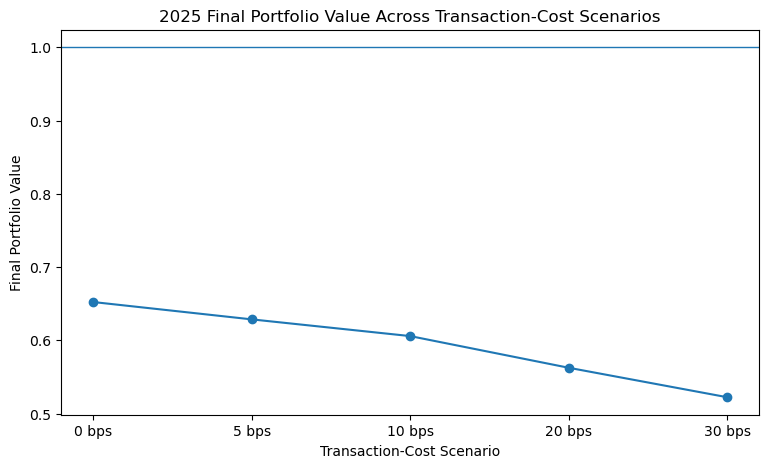

In [107]:
# step 16.3 plot transection sensitivity 
plt.figure(figsize=(9, 5))

plt.plot(
    cost_sensitivity_table.index,
    cost_sensitivity_table["Final Portfolio Value"],
    marker="o",
)

plt.axhline(1, linewidth=1)

plt.title(
    "2025 Final Portfolio Value Across Transaction-Cost Scenarios"
)

plt.xlabel("Transaction-Cost Scenario")
plt.ylabel("Final Portfolio Value")

plt.show()

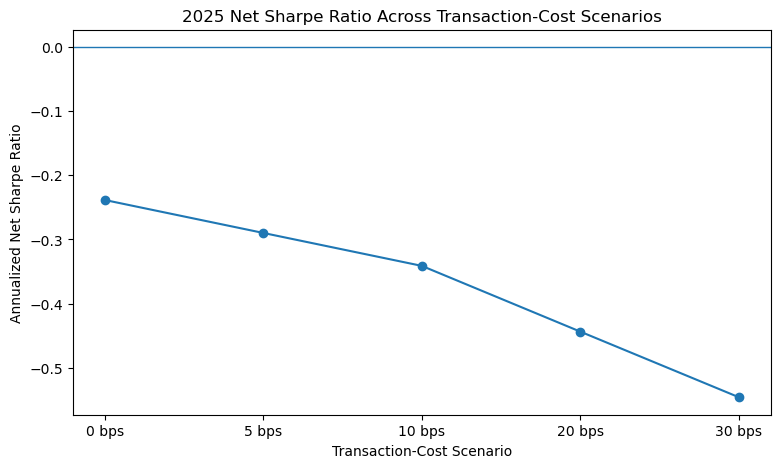

In [109]:
# step 16.3 plot sharpe
plt.figure(figsize=(9, 5))

plt.plot(
    cost_sensitivity_table.index,
    cost_sensitivity_table[
        "Annualized Net Sharpe Ratio"
    ],
    marker="o",
)

plt.axhline(0, linewidth=1)

plt.title(
    "2025 Net Sharpe Ratio Across Transaction-Cost Scenarios"
)

plt.xlabel("Transaction-Cost Scenario")
plt.ylabel("Annualized Net Sharpe Ratio")

plt.show()

### Transaction-Cost Sensitivity Finding

- Strategy performance deteriorated progressively as transaction costs increased.
- Final portfolio value declined from approximately 0.65 under the zero-cost scenario to approximately 0.52 under the 30-basis-point scenario.
- The annualized Sharpe Ratio was negative under every transaction-cost assumption.
- The strategy remained materially unprofitable even when transaction costs were assumed to be zero.
- Therefore, the 2025 out-of-sample failure was not primarily caused by the 20-basis-point execution-cost assumption.
- Higher transaction costs amplified the losses, but the underlying seven-day momentum signal had already generated negative gross performance.
- The conclusion that the model failed out of sample was robust across all tested transaction-cost scenarios.

## Step 17: Daily-Return Regression Robustness Analysis

The primary alpha-beta analysis was conducted using hourly returns.

As a robustness test, hourly strategy and benchmark returns are compounded into daily returns, and the alpha-beta regression is re-estimated at the daily frequency.

This test assesses whether the conclusions of high market beta and limited independent alpha remain unchanged when a lower-frequency return series is used.

In [116]:
# Step 17.1: compound hourly returns into daily returns

daily_regression_data = pd.DataFrame(
    {
        "momentum_net_return": (
            validation_strategy["net_return"]
        ),
        "benchmark_net_return": (
            validation_benchmark["net_return"]
        ),
    }
).dropna()

daily_regression_data = (
    daily_regression_data
    .resample("1D")
    .apply(
        lambda returns: (
            1 + returns
        ).prod() - 1
    )
)

print(daily_regression_data.shape)
daily_regression_data.head()

(365, 2)


,momentum_net_return,benchmark_net_return
open_time,,
2025-01-01 00:00:00+00:00,0.0,0.0
2025-01-02 00:00:00+00:00,0.0,0.0
2025-01-03 00:00:00+00:00,0.0,0.0
2025-01-04 00:00:00+00:00,0.0,0.0
2025-01-05 00:00:00+00:00,0.0,0.0


In [118]:
# Step 17.2: estimate daily alpha and beta

X_daily = sm.add_constant(
    daily_regression_data["benchmark_net_return"]
)

y_daily = daily_regression_data[
    "momentum_net_return"
]

daily_alpha_beta_model = sm.OLS(
    y_daily,
    X_daily,
).fit()

print(daily_alpha_beta_model.summary())

                             OLS Regression Results                            
Dep. Variable:     momentum_net_return   R-squared:                       0.857
Model:                             OLS   Adj. R-squared:                  0.857
Method:                  Least Squares   F-statistic:                     2178.
Date:                 Thu, 30 Jul 2026   Prob (F-statistic):          1.83e-155
Time:                         10:59:59   Log-Likelihood:                 1042.0
No. Observations:                  365   AIC:                            -2080.
Df Residuals:                      363   BIC:                            -2072.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 

In [120]:
# Step 17.3: calculate HAC-robust daily standard errors

daily_alpha_beta_model_hac = (
    daily_alpha_beta_model.get_robustcov_results(
        cov_type="HAC",
        maxlags=5,
    )
)

print(
    daily_alpha_beta_model_hac.summary()
)

                             OLS Regression Results                            
Dep. Variable:     momentum_net_return   R-squared:                       0.857
Model:                             OLS   Adj. R-squared:                  0.857
Method:                  Least Squares   F-statistic:                     798.5
Date:                 Thu, 30 Jul 2026   Prob (F-statistic):           1.05e-93
Time:                         11:00:13   Log-Likelihood:                 1042.0
No. Observations:                  365   AIC:                            -2080.
Df Residuals:                      363   BIC:                            -2072.
Df Model:                            1                                         
Covariance Type:                   HAC                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 

In [122]:
# Step 17.4: extract daily regression results

daily_alpha = (
    daily_alpha_beta_model_hac.params[0]
)

daily_beta = (
    daily_alpha_beta_model_hac.params[1]
)

daily_alpha_p_value = (
    daily_alpha_beta_model_hac.pvalues[0]
)

daily_beta_p_value = (
    daily_alpha_beta_model_hac.pvalues[1]
)

daily_r_squared = (
    daily_alpha_beta_model.rsquared
)

daily_annualized_alpha_arithmetic = (
    daily_alpha * 365
)

daily_alpha_beta_summary = pd.Series(
    {
        "Daily Alpha": daily_alpha,
        "Annualized Alpha - Arithmetic": (
            daily_annualized_alpha_arithmetic
        ),
        "Daily Beta": daily_beta,
        "Alpha P-Value": daily_alpha_p_value,
        "Beta P-Value": daily_beta_p_value,
        "R-Squared": daily_r_squared,
    }
)

daily_alpha_beta_summary

Daily Alpha                     -3.367017e-04
Annualized Alpha - Arithmetic   -1.228961e-01
Daily Beta                       9.218058e-01
Alpha P-Value                    6.302569e-01
Beta P-Value                     1.052717e-93
R-Squared                        8.571577e-01
dtype: float64

In [ ]:
# daily regression: alpha -0.03367,Annualized Alpha -0.1229,.... similar as 
# hourly regression: alpha negative, beta 0.9384, alpha p-value 0.6473, r squared 0.8753
# daily alpha is nagative, not significant
# daily beta positive high, siganificant
# r square high

### Daily-Return Regression Robustness Finding

- The alpha-beta regression was re-estimated using compounded daily returns instead of hourly returns.
- The estimated daily beta was approximately 0.92 and remained highly statistically significant.
- The daily alpha was negative but statistically insignificant, with a p-value of approximately 0.63.
- Approximately 85.7% of the variation in daily strategy returns was explained by the equal-weight cryptocurrency benchmark.
- These results were consistent with the hourly regression, which produced a beta of approximately 0.94 and an R-squared of approximately 87.5%.
- The main validation conclusion was therefore robust to the choice of return frequency.
- The strategy remained primarily exposed to broad cryptocurrency market movements and did not demonstrate statistically significant independent momentum-selection alpha.

## Step 18: Development vs Validation Comparison

The model's 2023–2024 development performance is compared with its 2025 out-of-sample validation performance.

This comparison assesses whether the model's profitability, risk-adjusted performance, drawdown and turnover remained stable outside the development sample.

In [127]:
# Step 18.1: load development-period summary

from pathlib import Path

development_summary_path = Path(
    "/Users/nimo/crypto-statistical-arbitrage/"
    "results/model_development/"
    "weekly_momentum_development_summary.csv"
)

development_summary_loaded = (
    pd.read_csv(
        development_summary_path,
        index_col=0,
    )
    .iloc[:, 0]
)

development_summary_loaded

average_hourly_net_return        0.000110
hourly_net_volatility            0.007648
annualized_net_sharpe_ratio      1.350581
net_maximum_drawdown            -0.573262
final_portfolio_value            4.144756
average_turnover                 0.007885
number_of_rebalances           104.000000
Name: development_2023_2024, dtype: float64

In [129]:
# Step 18.2: create validation-period summary

validation_net_return = (
    validation_strategy["net_return"]
    .fillna(0)
)

validation_net_mean = (
    validation_net_return.mean()
)

validation_net_vol = (
    validation_net_return.std()
)

validation_net_sharpe_for_comparison = (
    validation_net_mean
    / validation_net_vol
    * np.sqrt(HOURS_PER_YEAR)
)

validation_net_mdd_for_comparison = (
    calculate_maximum_drawdown(
        validation_net_return
    )
)

validation_final_portfolio_value = (
    1 + validation_net_return
).cumprod().iloc[-1]

In [131]:
validation_summary_for_comparison = pd.Series(
    {
        "average_hourly_net_return": (
            validation_net_mean
        ),

        "hourly_net_volatility": (
            validation_net_vol
        ),

        "annualized_net_sharpe_ratio": (
            validation_net_sharpe_for_comparison
        ),

        "net_maximum_drawdown": (
            validation_net_mdd_for_comparison
        ),

        "final_portfolio_value": (
            validation_final_portfolio_value
        ),

        "average_turnover": (
            validation_strategy["turnover"].mean()
        ),

        "number_of_rebalances": (
            validation_strategy["turnover"]
            .gt(0)
            .sum()
        ),
    },
    name="validation_2025",
)

validation_summary_for_comparison

average_hourly_net_return      -0.000036
hourly_net_volatility           0.007652
annualized_net_sharpe_ratio    -0.443891
net_maximum_drawdown           -0.558106
final_portfolio_value           0.562608
average_turnover                0.008409
number_of_rebalances           52.000000
Name: validation_2025, dtype: float64

In [133]:
# Step 18.3: combine development and validation summaries

development_validation_comparison = pd.concat(
    [
        development_summary_loaded,
        validation_summary_for_comparison,
    ],
    axis=1,
)

development_validation_comparison.columns = [
    "Development 2023–2024",
    "Validation 2025",
]

development_validation_comparison

,Development 2023–2024,Validation 2025
average_hourly_net_return,0.000110,-0.000036
hourly_net_volatility,0.007648,0.007652
annualized_net_sharpe_ratio,1.350581,-0.443891
net_maximum_drawdown,-0.573262,-0.558106
final_portfolio_value,4.144756,0.562608
average_turnover,0.007885,0.008409
number_of_rebalances,104.000000,52.000000


In [135]:
# step 18.4 more detailed table
development_validation_comparison.index = [
    "Average Hourly Net Return",
    "Hourly Net Volatility",
    "Annualized Net Sharpe Ratio",
    "Net Maximum Drawdown",
    "Final Portfolio Value",
    "Average Turnover",
    "Number of Rebalances",
]

development_validation_comparison

,Development 2023–2024,Validation 2025
Average Hourly Net Return,0.000110,-0.000036
Hourly Net Volatility,0.007648,0.007652
Annualized Net Sharpe Ratio,1.350581,-0.443891
Net Maximum Drawdown,-0.573262,-0.558106
Final Portfolio Value,4.144756,0.562608
Average Turnover,0.007885,0.008409
Number of Rebalances,104.000000,52.000000


In [137]:
# step 18.5 add more column
development_validation_comparison[
    "Validation Minus Development"
] = (
    development_validation_comparison[
        "Validation 2025"
    ]
    - development_validation_comparison[
        "Development 2023–2024"
    ]
)

development_validation_comparison

,Development 2023–2024,Validation 2025,Validation Minus Development
Average Hourly Net Return,0.000110,-0.000036,-0.000147
Hourly Net Volatility,0.007648,0.007652,0.000004
Annualized Net Sharpe Ratio,1.350581,-0.443891,-1.794472
Net Maximum Drawdown,-0.573262,-0.558106,0.015156
Final Portfolio Value,4.144756,0.562608,-3.582148
Average Turnover,0.007885,0.008409,0.000524
Number of Rebalances,104.000000,52.000000,-52.000000


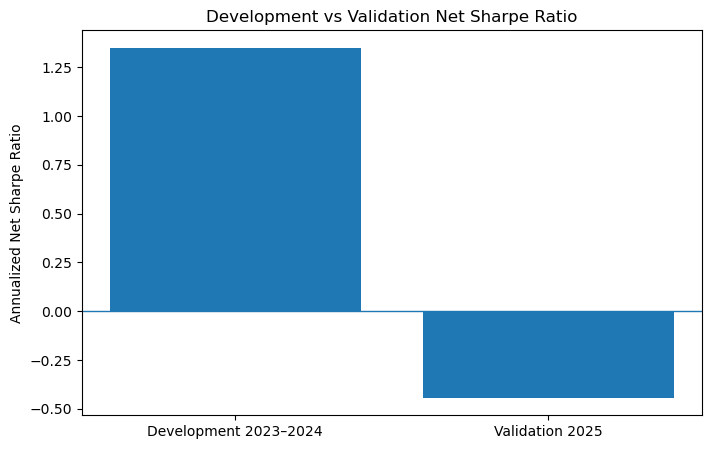

In [139]:
# step 18.6 sharpe 
plt.figure(figsize=(8, 5))

plt.bar(
    [
        "Development 2023–2024",
        "Validation 2025",
    ],
    [
        development_validation_comparison.loc[
            "Annualized Net Sharpe Ratio",
            "Development 2023–2024",
        ],
        development_validation_comparison.loc[
            "Annualized Net Sharpe Ratio",
            "Validation 2025",
        ],
    ],
)

plt.axhline(0, linewidth=1)

plt.title(
    "Development vs Validation Net Sharpe Ratio"
)

plt.ylabel("Annualized Net Sharpe Ratio")

plt.show()

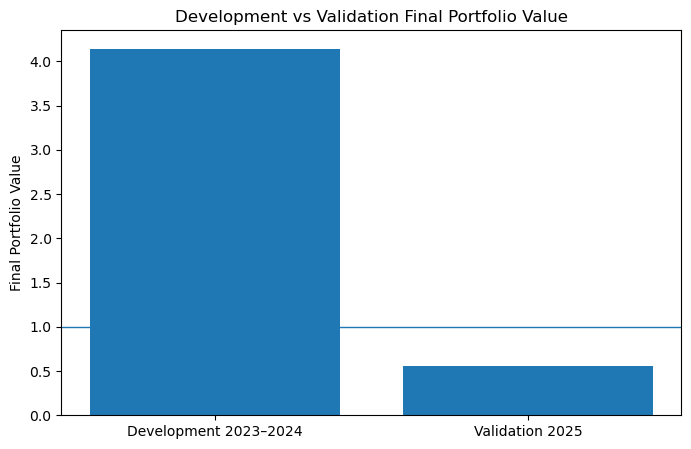

In [141]:
# step 18.7 final portfolio value compare
plt.figure(figsize=(8, 5))

plt.bar(
    [
        "Development 2023–2024",
        "Validation 2025",
    ],
    [
        development_validation_comparison.loc[
            "Final Portfolio Value",
            "Development 2023–2024",
        ],
        development_validation_comparison.loc[
            "Final Portfolio Value",
            "Validation 2025",
        ],
    ],
)

plt.axhline(1, linewidth=1)

plt.title(
    "Development vs Validation Final Portfolio Value"
)

plt.ylabel("Final Portfolio Value")

plt.show()

### Development vs Validation Finding

- Average hourly net return changed from positive during the 2023–2024 development period to negative during the 2025 validation period.
- The annualized net Sharpe Ratio declined substantially from approximately 1.35 to approximately -0.44.
- Final portfolio value increased to approximately 4.14 during development but declined to approximately 0.56 during validation.
- Hourly volatility remained almost unchanged across the two periods.
- Maximum Drawdown remained severe in both samples, at approximately 56%–57%.
- Average turnover was broadly stable, and the number of rebalances remained consistent at approximately 52 per year.
- Therefore, the deterioration in validation performance was not caused by materially higher volatility, turnover or a change in portfolio implementation.
- The results indicate that development-sample profitability was not stable out of sample.
- This represents a material performance-stability limitation and suggests that the seven-day momentum signal was dependent on the prevailing cryptocurrency market regime.

## Step 19: Validation Findings and Model Limitations

### 1. Out-of-Sample Performance Failure

- The weekly long-only momentum strategy generated positive net returns during the 2023–2024 development period.
- However, the same frozen strategy produced negative gross and net returns during the 2025 out-of-sample validation period.
- The annualized net Sharpe Ratio declined from approximately 1.35 during development to approximately -0.44 during validation.
- Final portfolio value declined to approximately 0.56 during the validation period.
- This indicates that the model's development-sample profitability was not stable out of sample.

### 2. Benchmark Underperformance

- Both the weekly momentum strategy and the equal-weight cryptocurrency benchmark produced negative returns during 2025.
- However, the momentum strategy produced a lower final portfolio value, a more negative Sharpe Ratio and a larger Maximum Drawdown.
- The momentum strategy also generated substantially higher turnover.
- Therefore, the top-three momentum selection rule did not add value relative to a simple diversified cryptocurrency portfolio.

### 3. No Statistically Significant Alpha

- The hourly alpha-beta regression produced a slightly negative alpha.
- The estimated alpha was not statistically significant.
- The daily-return robustness regression produced the same conclusion.
- There was therefore no statistical evidence that the momentum-selection rule generated persistent benchmark-relative alpha.

### 4. High Market Beta and Market Dependence

- The estimated beta was approximately 0.94 using hourly returns and approximately 0.92 using daily returns.
- Both beta estimates were highly statistically significant.
- Approximately 86%–88% of strategy-return variation was explained by the equal-weight cryptocurrency benchmark.
- The strategy's performance was therefore primarily driven by broad cryptocurrency market exposure rather than an independent momentum-selection effect.

### 5. Transaction-Cost Sensitivity

- Strategy performance deteriorated progressively as transaction costs increased.
- However, the strategy remained materially unprofitable even under the zero-cost scenario.
- The annualized Sharpe Ratio remained negative under every tested transaction-cost assumption.
- Therefore, the 2025 out-of-sample failure was not primarily caused by the assumed 20-basis-point execution cost.
- The underlying seven-day momentum signal generated negative gross performance during validation.

### 6. High Drawdown and Concentration Risk

- The strategy experienced a Maximum Drawdown of approximately 56%–57% in both development and validation samples.
- The portfolio held only three cryptocurrencies at each rebalance date.
- This created material concentration risk and reduced diversification relative to the ten-asset equal-weight benchmark.
- The strategy therefore exposed investors to substantial downside risk without delivering stable out-of-sample returns.

### 7. Market-Regime Dependence

- The strategy performed strongly during the 2023–2024 development period but failed during 2025.
- Volatility and turnover remained broadly similar across the two samples.
- The deterioration therefore appears more consistent with changing market conditions than with a change in implementation.
- The seven-day momentum signal appears sensitive to cryptocurrency market regime.

## Model Limitations

- The analysis used only ten cryptocurrencies.
- The selected assets were current and liquid cryptocurrencies, creating potential survivorship bias.
- The full sample covered only three years.
- The out-of-sample validation period covered only one year.
- Transaction costs were represented using a fixed basis-point assumption.
- The model did not include dynamic bid-ask spreads, market impact or order-size constraints.
- Funding costs, borrowing constraints and exchange-specific risks were not modelled.
- The equal-weight benchmark used a simplified constant-weight implementation.
- The strategy was long-only and therefore retained substantial market beta.
- The portfolio was concentrated in only three assets.
- The model did not include explicit volatility targeting, stop-loss rules or drawdown controls.
- The analysis did not test performance across multiple independent cryptocurrency market cycles.

### Overall Validation Assessment

The model implementation was consistent with the documented strategy specification.

However, the model failed to demonstrate stable out-of-sample profitability, benchmark-relative outperformance or statistically significant alpha. Its returns were primarily explained by broad cryptocurrency market exposure, while drawdown and concentration risk remained high.

The model is therefore not considered sufficiently robust for standalone investment use in its current form.

## Step 20: Validation Decision and Recommendations

### Validation Decision

The weekly long-only cryptocurrency momentum model is **not recommended for standalone investment use in its current form**.

The model implementation was consistent with the documented strategy specification, and the portfolio construction, weekly rebalancing, transaction-cost treatment and performance calculations were implemented as intended.

However, the model did not demonstrate sufficiently stable or independent predictive performance during validation:

- The strategy generated positive net returns during the 2023–2024 development period but negative gross and net returns during the 2025 out-of-sample period.
- The annualized net Sharpe Ratio declined from approximately 1.35 during development to approximately -0.44 during validation.
- The strategy underperformed the equal-weight cryptocurrency benchmark during 2025.
- Alpha was not statistically significant at either hourly or daily frequency.
- Beta remained close to one, and approximately 86%–88% of return variation was explained by the broad cryptocurrency benchmark.
- The strategy remained unprofitable even under a zero-transaction-cost scenario.
- Maximum Drawdown remained severe at approximately 56%–57%.
- The portfolio was concentrated in only three cryptocurrencies at each rebalance date.

These findings indicate that the model's development-period profitability was not stable out of sample and was largely dependent on broad cryptocurrency market conditions.

### Recommended Model Status

- The model should remain classified as a research or exploratory model.
- It should not be presented as a validated standalone alpha strategy.
- It should not be deployed using material capital without further redevelopment and independent testing.
- Any future use should be subject to strict exposure limits, drawdown controls and ongoing performance monitoring.

### Recommendations for Redevelopment

1. **Extend the historical sample**

   - Test the model across a longer period containing multiple cryptocurrency market cycles.
   - Include bull, bear, high-volatility and low-volatility regimes.
   - Use multiple rolling or expanding out-of-sample validation windows.

2. **Improve asset-universe construction**

   - Expand the cryptocurrency universe beyond ten assets.
   - Apply transparent liquidity and data-availability rules.
   - Include delisted or inactive assets where possible to reduce survivorship bias.

3. **Reduce concentration risk**

   - Evaluate more diversified portfolio constructions.
   - Introduce maximum asset-weight limits.
   - Consider volatility-scaled rather than equal weighting.

4. **Introduce explicit risk controls**

   - Add portfolio volatility targeting.
   - Establish drawdown limits and risk-reduction rules.
   - Monitor market beta and concentration exposures.
   - Consider reducing exposure during highly adverse market regimes.

5. **Improve execution-cost modelling**

   - Replace the fixed transaction-cost assumption with asset- and time-dependent bid-ask spread estimates.
   - Incorporate market impact, order size and liquidity constraints.
   - Assess execution assumptions under stressed market conditions.

6. **Assess market-regime dependence**

   - Test whether momentum performance differs across trending, reversing and high-volatility environments.
   - Predefine regime variables using only information available at the time.
   - Avoid selecting regimes based on validation-period performance.

7. **Improve benchmark and performance attribution**

   - Compare performance with additional market benchmarks, such as BTC buy-and-hold or a properly rebalanced equal-weight portfolio.
   - Separate market beta, asset-selection effects and execution-cost effects.
   - Continue reporting alpha significance using robust standard errors.

8. **Establish ongoing monitoring thresholds**

   - Monitor rolling return, Sharpe Ratio, Maximum Drawdown, turnover, beta and benchmark-relative performance.
   - Define thresholds for performance deterioration.
   - Require model review if thresholds are breached or market conditions materially change.

### Final Validation Opinion

The model is transparent and correctly implemented, but it does not currently provide sufficient evidence of stable, benchmark-relative momentum alpha.

